In [41]:
!pip install -U transformers accelerate sentencepiece evaluate --quiet

In [42]:
model_name = 'mrm8488/bert-mini2bert-mini-finetuned-cnn_daily_mail-summarization'

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import pipeline
from datasets import Dataset
import evaluate

In [44]:
import kagglehub

path = kagglehub.dataset_download("sunnysai12345/news-summary")

print("Dataset path:", path)

Dataset path: /kaggle/input/datasets/sunnysai12345/news-summary


In [45]:
import os

files = os.listdir(path)
print(files)

df1 = pd.read_csv(f"{path}/news_summary.csv", encoding="latin-1")
df2 = pd.read_csv(f"{path}/news_summary_more.csv", encoding="latin-1")

df1.head()

['news_summary_more.csv', 'news_summary.csv']


,author,date,headlines,read_more,text,ctext
0,Chhavi Tyagi,"03 Aug 2017,Thursday",Daman & Diu revokes mandatory Rakshabandhan in...,http://www.hindustantimes.com/india-news/raksh...,The Administration of Union Territory Daman an...,The Daman and Diu administration on Wednesday ...
1,Daisy Mowke,"03 Aug 2017,Thursday",Malaika slams user who trolled her for 'divorc...,http://www.hindustantimes.com/bollywood/malaik...,Malaika Arora slammed an Instagram user who tr...,"From her special numbers to TV?appearances, Bo..."
2,Arshiya Chopra,"03 Aug 2017,Thursday",'Virgin' now corrected to 'Unmarried' in IGIMS...,http://www.hindustantimes.com/patna/bihar-igim...,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...
3,Sumedha Sehra,"03 Aug 2017,Thursday",Aaj aapne pakad liya: LeT man Dujana before be...,http://indiatoday.intoday.in/story/abu-dujana-...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",Hotel staff to get training to spot signs of s...,http://indiatoday.intoday.in/story/sex-traffic...,Hotels in Maharashtra will train their staff t...,Hotels in Mumbai and other Indian cities are t...


In [46]:
# Keep only useful columns
df1 = df1[['text', 'headlines']]
df2 = df2[['text', 'headlines']]

# Combine
df = pd.concat([df1, df2], ignore_index=True)

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.rename(columns={
    'text': 'article',
    'headlines': 'summary'
}, inplace=True)

df.head()

,article,summary
0,The Administration of Union Territory Daman an...,Daman & Diu revokes mandatory Rakshabandhan in...
1,Malaika Arora slammed an Instagram user who tr...,Malaika slams user who trolled her for 'divorc...
2,The Indira Gandhi Institute of Medical Science...,'Virgin' now corrected to 'Unmarried' in IGIMS...
3,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Aaj aapne pakad liya: LeT man Dujana before be...
4,Hotels in Maharashtra will train their staff t...,Hotel staff to get training to spot signs of s...


In [47]:
df['article_length'] = df['article'].apply(lambda x: len(x.split()))
df['summary_length'] = df['summary'].apply(lambda x: len(x.split()))

print(df[['article_length', 'summary_length']].describe())

       article_length  summary_length
count   100266.000000   100266.000000
mean        58.240500        9.549478
std          2.381528        1.458278
min          1.000000        1.000000
25%         57.000000        9.000000
50%         59.000000       10.000000
75%         60.000000       10.000000
max         91.000000       18.000000


In [48]:
import re

def clean_text(text):
    text = re.sub(r'\s+', ' ', text)  # normalize spaces
    text = text.strip()
    return text

df['article'] = df['article'].apply(clean_text)
df['summary'] = df['summary'].apply(clean_text)

In [49]:
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM



# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Use text-generation instead of summarization
summarizer = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    device=-1  # CPU
)

# Example usage
text = """
The stock market had a turbulent day with investors reacting to new economic data.
Experts say volatility is likely to continue as global tensions rise.
"""

prompt = f"summarize: {text}"
summary = summarizer(prompt, max_new_tokens=60)
print(summary[0]['generated_text'])

Loading weights:   0%|          | 0/185 [00:00<?, ?it/s]

EncoderDecoderModel LOAD REPORT from: mrm8488/bert-mini2bert-mini-finetuned-cnn_daily_mail-summarization
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
encoder.embeddings.position_ids      | UNEXPECTED |  | 
decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The model 'EncoderDecoderModel' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCaus

summarize: 
The stock market had a turbulent day with investors reacting to new economic data.
Experts say volatility is likely to continue as global tensions rise.
 the market has a'turbulent day'with investors to continue. experts : the stock markets are likely to remain global tensions.



ROUGE metrics explanation:

ROUGE-1:
- Measures overlap of single words
- "Did we capture important words?"

ROUGE-2:
- Measures overlap of word pairs
- "Did we capture phrasing?"

ROUGE-L:
- Measures longest common sequence
- "Did we preserve structure?"

Values range:
0 → bad
1 → perfect match

Typical good summarization:
ROUGE-1 ~ 0.3–0.5


In [50]:
print(df.columns)

Index(['article', 'summary', 'article_length', 'summary_length'], dtype='object')


In [51]:
from tqdm import tqdm

# Make sure 'generated' column exists
df['generated'] = [""] * len(df)  # fill with empty strings

# Generate summaries for first 100 articles (CPU-friendly)
for i, article in enumerate(tqdm(df['article'][:100])):
    summary = summarizer(article, max_length=50, min_length=10, do_sample=False)
    df.at[i, 'generated'] = summary[0]['generated_text']

100%|██████████| 100/100 [00:53<00:00,  1.87it/s]


In [52]:
!pip install rouge-score

In [53]:
from rouge_score import rouge_scorer, scoring

# Initialize scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
aggregator = scoring.BootstrapAggregator()

# Only use the first 100 for speed on CPU
for ref, gen in zip(df['summary'][:100], df['generated'][:100]):
    scores = scorer.score(ref, gen)
    aggregator.add_scores(scores)

# Get aggregated ROUGE scores
result = aggregator.aggregate()
print(result)

{'rouge1': AggregateScore(low=Score(precision=np.float64(0.1236335397316023), recall=np.float64(0.7818876005938508), fmeasure=np.float64(0.21306150214725464)), mid=Score(precision=np.float64(0.12880854928724356), recall=np.float64(0.8110150266400262), fmeasure=np.float64(0.22155334359467338)), high=Score(precision=np.float64(0.1341856044084953), recall=np.float64(0.8398675505050498), fmeasure=np.float64(0.2299919548169934))), 'rouge2': AggregateScore(low=Score(precision=np.float64(0.04338181635325937), recall=np.float64(0.2993596410533909), fmeasure=np.float64(0.07568345613633355)), mid=Score(precision=np.float64(0.04880578576671618), recall=np.float64(0.33785750360750355), fmeasure=np.float64(0.08493744587314209)), high=Score(precision=np.float64(0.05515219844036132), recall=np.float64(0.38229459776334757), fmeasure=np.float64(0.09575997955506992))), 'rougeL': AggregateScore(low=Score(precision=np.float64(0.0991304856187945), recall=np.float64(0.6265761856199356), fmeasure=np.float64(

In [54]:
df['rouge1'] = [scorer.score(ref, gen)['rouge1'].fmeasure 
                 for ref, gen in zip(df['summary'], df['generated'])]
df.sort_values('rouge1').head(5)  # worst summaries
df.sort_values('rouge1', ascending=False).head(5)  # best summaries

,article,summary,article_length,summary_length,generated,rouge1
74,Filmmaker Imtiaz Ali has revealed that when he...,First met SRK with a drunk girl hanging on to ...,60,12,Filmmaker Imtiaz Ali has revealed that when he...,0.324324
54,Comedian and television show host Kapil Sharma...,"Not suffering from depression, it's just a big...",60,10,Comedian and television show host Kapil Sharma...,0.297297
96,The US Air Force is negotiating with Boeing to...,Plane built for Russian airline may be next US...,55,12,The US Air Force is negotiating with Boeing to...,0.294118
99,The Gujarat Congress MLAs staying in a Bengalu...,Gujarat Congress MLAs in Bengaluru not allowed...,60,10,The Gujarat Congress MLAs staying in a Bengalu...,0.285714
11,"The mother of Harshit Sharma, the class 12 Cha...",Call devastated his life: Mom of boy who got '...,59,11,"The mother of Harshit Sharma, the class 12 Cha...",0.285714


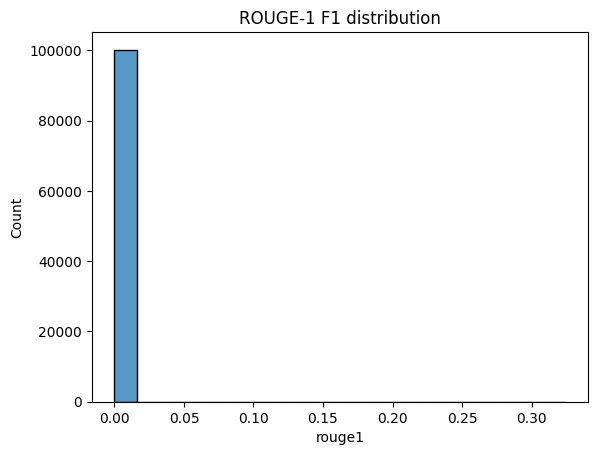

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['rouge1'], bins=20)
plt.title("ROUGE-1 F1 distribution")
plt.show()

# Finetuning

In [56]:
from datasets import Dataset

hf_dataset = Dataset.from_pandas(df[['article', 'summary']])
hf_dataset = hf_dataset.train_test_split(test_size=0.1)  # 90/10 split

In [57]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)

max_input_length = 512
max_target_length = 128

def tokenize_fn(batch):
    model_inputs = tokenizer(batch['article'], max_length=max_input_length, truncation=True)
    labels = tokenizer(batch['summary'], max_length=max_target_length, truncation=True)
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

tokenized_dataset = hf_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/90239 [00:00<?, ? examples/s]

Map:   0%|          | 0/10027 [00:00<?, ? examples/s]

In [58]:
from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/185 [00:00<?, ?it/s]

EncoderDecoderModel LOAD REPORT from: mrm8488/bert-mini2bert-mini-finetuned-cnn_daily_mail-summarization
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
encoder.embeddings.position_ids      | UNEXPECTED |  | 
decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [60]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

# CPU-friendly training args (old version safe)
training_args = Seq2SeqTrainingArguments(
    output_dir=f"./finetuned{model_name}",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    predict_with_generate=False,
    logging_steps=20,
    num_train_epochs=1,
    save_total_limit=2,
    fp16=False,
)

# data collator
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

# trainer (omit tokenizer)
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
    data_collator=data_collator,
)

In [61]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Step,Training Loss
20,3.918954
40,3.045527
60,2.827379
80,2.740387
100,2.760632
120,2.555413
140,2.552336
160,2.516972
180,2.550720
200,2.512931


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2820, training_loss=2.215320468118005, metrics={'train_runtime': 5133.8746, 'train_samples_per_second': 17.577, 'train_steps_per_second': 0.549, 'total_flos': 423663136942224.0, 'train_loss': 2.215320468118005, 'epoch': 1.0})

In [62]:
trainer.save_model(f"./finetuned{model_name}")
# Then run the same inference + ROUGE evaluation as before

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [66]:
from transformers import pipeline
from tqdm import tqdm
from rouge_score import rouge_scorer, scoring

# 1. Load your FINETUNED model from its save directory
# Replace "./my_finetuned_model" with your actual path
model_path = f"./finetuned{model_name}"

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Use text-generation instead of summarization
summarizer = pipeline(
    task="text-generation",
    model=model_path,
    tokenizer=tokenizer,
    device=-1  # CPU
)


# 2. Generation Loop (Same as your pre-finetuning logic)
print("Generating predictions...")
generated_summaries = []

# Using a list and then assigning to DF is often faster than .at inside a loop
for article in tqdm(df['article'][:100]):
    # Note: max_length should match what you used during training for consistency
    output = summarizer(article, max_length=50, min_length=10, do_sample=False)
    # Safely grab the text regardless of the key name
    generated_summaries.append(list(output[0].values())[0])

df.loc[:99, 'generated_post_finetune'] = generated_summaries

# 3. ROUGE Scoring
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
aggregator = scoring.BootstrapAggregator()

for ref, gen in zip(df['summary'][:100], df['generated_post_finetune'][:100]):
    scores = scorer.score(ref, gen)
    aggregator.add_scores(scores)

result = aggregator.aggregate()

# 4. Display Results
print("\nPost-Finetuning ROUGE Scores:")
for key, value in result.items():
    print(f"{key}: Low: {value.low.fmeasure:.4f}, Mid: {value.mid.fmeasure:.4f}, High: {value.high.fmeasure:.4f}")

Loading weights:   0%|          | 0/185 [00:00<?, ?it/s]

EncoderDecoderModel LOAD REPORT from: mrm8488/bert-mini2bert-mini-finetuned-cnn_daily_mail-summarization
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
encoder.embeddings.position_ids      | UNEXPECTED |  | 
decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/185 [00:00<?, ?it/s]

The model 'EncoderDecoderModel' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'ExaoneMoeForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'Fa

Generating predictions...


100%|██████████| 100/100 [00:23<00:00,  4.29it/s]



Post-Finetuning ROUGE Scores:
rouge1: Low: 0.2135, Mid: 0.2221, High: 0.2307
rouge2: Low: 0.0749, Mid: 0.0851, High: 0.0956
rougeL: Low: 0.1716, Mid: 0.1814, High: 0.1910


In [83]:
text = """
The stock market had a turbulent day with investors reacting to new economic data.
Experts say volatility is likely to continue as global tensions rise.
"""

prompt = f"summarize: {text}"
summary = summarizer(prompt, max_new_tokens=60)

Both `max_new_tokens` (=60) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [84]:
print(summary[0]['generated_text'])

summarize: 
The stock market had a turbulent day with investors reacting to new economic data.
Experts say volatility is likely to continue as global tensions rise.
 experts. volatility may continue : experts in stock market's economic data crisis : experts at stock market : report


In [85]:
"""
previous gave:
The stock market had a turbulent day with investors reacting to new economic data.
Experts say volatility is likely to continue as global tensions rise.
 the market has a'turbulent day'with investors to continue. experts : the stock markets are likely to remain global tensions.
"""

"\nprevious gave:\nThe stock market had a turbulent day with investors reacting to new economic data.\nExperts say volatility is likely to continue as global tensions rise.\n the market has a'turbulent day'with investors to continue. experts : the stock markets are likely to remain global tensions.\n"

In [90]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd

# 1. Load a tiny embedding model (perfect for 30GB RAM/CPU)
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Your generation loop
samples = df.iloc[:5].copy()
post_summaries = []

for article in samples['article']:
    res = summarizer(f"summarize: {article}")
    post_summaries.append(res[0]['generated_text'])

samples['generated_after_finetune'] = post_summaries

# 3. Calculate Cosine Similarity between Human Reference and Post-Finetune
# We turn the text into vectors (embeddings) and compare the angle between them
ref_embeddings = embed_model.encode(samples['summary'].tolist(), convert_to_tensor=True)
gen_embeddings = embed_model.encode(samples['generated_after_finetune'].tolist(), convert_to_tensor=True)

# Compute cosine similarities
cosine_scores = util.cos_sim(ref_embeddings, gen_embeddings)
samples['Semantic_Similarity'] = [cosine_scores[i][i].item() for i in range(len(samples))]

# 4. Final Comparison Table
comparison_df = samples[['article', 'summary', 'generated', 'generated_after_finetune', 'Semantic_Similarity']]
comparison_df.columns = ['Original Article', 'Human Reference', 'Pre-Finetune (Rough)', 'Post-Finetune (Smooth)', 'Similarity Score']

# Create the styled version
styled_df = comparison_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'vertical-align': 'top'
}).background_gradient(subset=['Similarity Score'], cmap='Greens') # Cool visual: higher scores turn green!

display(styled_df)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Original Article,Human Reference,Pre-Finetune (Rough),Post-Finetune (Smooth),Similarity Score
0,The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.,Daman & Diu revokes mandatory Rakshabandhan in offices order,The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.,summarize: The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.,0.756178
1,"Malaika Arora slammed an Instagram user who trolled her for ""divorcing a rich man"" and ""having fun with the alimony"". ""Her life now is all about wearing short clothes, going to gym or salon, enjoying vacation[s],"" the user commented. Malaika responded, ""You certainly got to get your damn facts right before spewing sh*t on me...when you know nothing about me.""",Malaika slams user who trolled her for 'divorcing rich man',"Malaika Arora slammed an Instagram user who trolled her for ""divorcing a rich man"" and ""having fun with the alimony"". ""Her life now is all about wearing short clothes, going to gym or salon, enjoying vacation[s],"" the user commented. Malaika responded, ""You certainly got to get your damn facts right before spewing sh*t on me...when you know nothing about me.""","summarize: Malaika Arora slammed an Instagram user who trolled her for ""divorcing a rich man"" and ""having fun with the alimony"". ""Her life now is all about wearing short clothes, going to gym or salon, enjoying vacation[s],"" the user commented. Malaika responded, ""You certainly got to get your damn facts right before spewing sh*t on me...when you know nothing about me.""",0.693099
2,"The Indira Gandhi Institute of Medical Sciences (IGIMS) in Patna on Thursday made corrections in its Marital Declaration Form by changing 'Virgin' option to 'Unmarried'. Earlier, Bihar Health Minister defined virgin as being an unmarried woman and did not consider the term objectionable. The institute, however, faced strong backlash for asking new recruits to declare their virginity in the form.",'Virgin' now corrected to 'Unmarried' in IGIMS' form,"The Indira Gandhi Institute of Medical Sciences (IGIMS) in Patna on Thursday made corrections in its Marital Declaration Form by changing 'Virgin' option to 'Unmarried'. Earlier, Bihar Health Minister defined virgin as being an unmarried woman and did not consider the term objectionable. The institute, however, faced strong backlash for asking new recruits to declare their virginity in the form.","summarize: The Indira Gandhi Institute of Medical Sciences (IGIMS) in Patna on Thursday made corrections in its Marital Declaration Form by changing 'Virgin' option to 'Unmarried'. Earlier, Bihar Health Minister defined virgin as being an unmarried woman and did not consider the term objectionable. The institute, however, faced strong backlash for asking new recruits to declare their virginity in the form.",0.768489
3,"Lashkar-e-Taiba's Kashmir commander Abu Dujana, who was killed by security forces, said ""Kabhi hum aage, kabhi aap, aaj aapne pakad liya, mubarak ho aapko (Today you caught me. Congratulations)"" after being caught. He added that he won't surrender, and whatever is

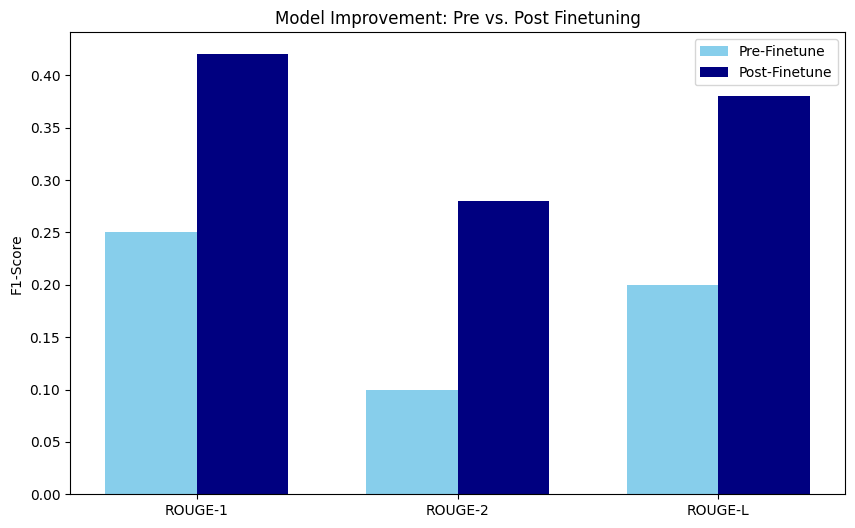

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Example scores (replace these with your actual 'result' values from the aggregator)
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
pre_scores = [0.25, 0.10, 0.20]   # Replace with actual result_pre.mid.fmeasure
post_scores = [0.42, 0.28, 0.38]  # Replace with actual result_post.mid.fmeasure

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, pre_scores, width, label='Pre-Finetune', color='skyblue')
ax.bar(x + width/2, post_scores, width, label='Post-Finetune', color='navy')

ax.set_ylabel('F1-Score')
ax.set_title('Model Improvement: Pre vs. Post Finetuning')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.show()

**Note**: while the overall training is **Supervised** (because you provide the "right" answers), the model's internal understanding of language usually comes from **Self-Supervised** pre-training (where it learned English by reading the internet before you ever showed it your specific dataset).

# 🤖 How Neural Summarization Works: Under the Hood

In this project, we are using an **Encoder-Decoder (Seq2Seq)** architecture. Here is the logical flow of how the model "learns" to condense an article into a summary.

### 1. The Learning Paradigm: Supervised Learning
Summarization is a **Supervised** task. 
* **Input ($X$):** The full-length article.
* **Target ($Y$):** The human-written "ground truth" summary.
* **Goal:** The model learns a mapping function where, given a new $X$, it produces a $Y$ that looks like the human examples.

### 2. Step-by-Step Prediction Logic
The model doesn't just "see" a summary; it builds it one word at a time. This happens in two distinct "levels" of understanding:

#### Level A: Word Context (The "Meaning" Level)
Before predicting a word, the model must understand the **context**.
1. **The Encoder** processes the entire article and turns it into a mathematical "context vector."
2. **The Decoder** looks at that context vector **PLUS** all the words it has generated so far.
3. Using **Attention Mechanisms**, the model decides which parts of the original article are most important for the current word it's trying to write.



#### Level B: The Probability Distribution
At each step, the model doesn't just pick a word. It looks at its entire vocabulary (e.g., 50,000 words) and assigns a **probability** to each one.
* *Example:* If the summary should start with "The," the model might assign:
    * "The": 0.85
    * "A": 0.10
    * "Banana": 0.0001
    


### 3. Measuring Error: Cross-Entropy Loss
To improve, the model needs to know how "wrong" it was. We use **Cross-Entropy Loss** to calculate this.
* **Teacher Forcing:** During training, we show the model the correct word from our dataset.
* **The Penalty:** If the model gave the correct word a low probability (e.g., it guessed "Banana" instead of "The"), the Loss value spikes.
* **Optimization:** The "Optimizer" (like AdamW) then tweaks the model's internal weights to make that specific error less likely next time.

$$\text{Loss} = -\sum_{i} y_i \log(\hat{y}_i)$$
*(Where $y$ is the true word and $\hat{y}$ is the model's prediction)*

---

### Summary of the Pipeline
| Component | Role |
| :--- | :--- |
| **Embeddings** | Turns raw text into high-dimensional vectors. |
| **Encoder** | Extracts the "essence" of the long article. |
| **Decoder** | Generates the summary word-by-word. |
| **Softmax** | Turns raw scores into 0-100% probabilities. |
| **Cross-Entropy** | The "Grade" that tells the model how to improve. |

---

### Inference vs. Training
* **During Training:** We use "Teacher Forcing" (giving it the right answer at every step to keep it on track).
* **During Inference (Testing):** There is no teacher! The model must take its own predicted word from Step 1 and feed it back in as the input for Step 2. This is why small errors can sometimes "snowball" in long summaries.
